<div align="center">

<h1> <b> MODELO DE DEPOSICIÓN ALEATORIA CON RELAJACIÓN SUPERFICIAL PARA EL CRECIMIENTO DE PELÍCULAS DELGADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y objetivos

Este proyecto estudia qué procesos físicos determinan la morfología de una película delgada de cobre (Cu) depositada sobre vidrio por evaporación térmica en una cámara de vacío. Los mecanismos físicos se incorporan uno a uno en cuadernos independientes, de modo que el efecto de cada uno sobre la morfología pueda distinguirse.

El cuaderno 1 de la serie trató la deposición aleatoria (RD), en la que cada partícula queda fija en la celda donde impacta. Su estadística es de Poisson y su rugosidad crece sin límite como $\sqrt{\overline{h}}$ (Barabási & Stanley, 1995). Este segundo cuaderno incorpora el primer mecanismo cinético: la movilidad superficial de corto alcance del átomo recién depositado. Para ello se implementa una generalización bidimensional de la **deposición aleatoria con relajación superficial** (*random deposition with surface relaxation*, RDSR), introducida por Family (1986) para una línea de sitios.

### Objetivos

* Implementar el algoritmo RDSR sobre una malla bidimensional discreta bajo la aproximación *solid-on-solid* (SOS).
* Compilar con Numba (Lam et al., 2015) la búsqueda de la celda de menor altura en la vecindad y el desempate estocástico de alturas.
* Analizar cuantitativamente cómo cambian la topografía y la rugosidad RMS al permitir un mecanismo de suavizado local, tomando el modelo RD como referencia analítica.

## 2. Marco teórico y modelo físico

### 2.1 Regla de deposición con relajación

En una evaporación térmica, los átomos de cobre que llegan al sustrato conservan parte de su energía y pueden desplazarse una corta distancia antes de fijarse, en busca de posiciones más estables, con más vecinos. En la aproximación SOS, la celda más baja de una vecindad es la que tiende a ofrecer más vecinos laterales. El modelo RDSR reproduce esta tendencia con una regla geométrica instantánea sobre una malla de $N_x \times N_y$ celdas, cuyas alturas enteras $h(i, j)$ cuentan capas efectivas, igual que en el modelo RD.

Cada evento de Monte Carlo sigue estos pasos:

1. Una partícula incide en una celda $(i, j)$ elegida con probabilidad uniforme $1/(N_x N_y)$.
2. Se consideran la celda de impacto y sus cuatro vecinos más cercanos (arriba, abajo, izquierda y derecha), que forman la vecindad
$$\mathcal{V}(i,j) = \{ (i,j), (i+1,j), (i-1,j), (i,j+1), (i,j-1) \},$$
restringida a las celdas que pertenecen a la malla.
3. Se calcula la altura mínima de la vecindad,
$$h_{\min} = \min_{(x,y) \in \mathcal{V}(i,j)} h(x,y).$$
4. La partícula se incorpora a una celda $(i^*, j^*) \in \mathcal{V}(i,j)$ con $h(i^*, j^*) = h_{\min}$. Si varias celdas cumplen esa condición, incluida la de impacto, se elige una con igual probabilidad.
5. Se actualiza la altura de la celda elegida: $h(i^*, j^*) \leftarrow h(i^*, j^*) + 1$.

Las fronteras son abiertas: las celdas fuera de la malla no forman parte de la vecindad, de modo que las celdas del borde tienen tres vecinos y las esquinas dos. Las celdas del borde son una fracción pequeña de la malla (cerca del 2 % para $200 \times 200$), por lo que se espera un efecto reducido sobre las métricas globales.

Family (1986) formuló el modelo para una línea de sitios. En esa formulación la partícula se deposita en el sitio de impacto siempre que ningún vecino sea más bajo, y solo en caso contrario migra al vecino más bajo (Buceta et al., 2014). La regla aquí implementada generaliza ese esquema a dos dimensiones con cuatro vecinos y resuelve los empates de manera uniforme entre todas las celdas de altura mínima, incluida la de impacto. La relajación ocurre en un solo paso hacia los vecinos inmediatos y no depende de la temperatura.

### 2.2 Magnitudes de caracterización morfológica

Como en el modelo RD, la morfología se caracteriza con el **espesor medio** y la **rugosidad RMS**, ambos en capas:

$$\overline{h} = \frac{1}{N_x N_y} \sum_{i=0}^{N_x-1} \sum_{j=0}^{N_y-1} h(i, j), \qquad W = \sqrt{\frac{1}{N_x N_y} \sum_{i=0}^{N_x-1} \sum_{j=0}^{N_y-1} \left(h(i, j) - \overline{h}\right)^2}.$$

El tiempo se mide en eventos de Monte Carlo, $N$, o en capas depositadas, $t = N/(N_x N_y)$, que coincide con $\overline{h}$.

### 2.3 Referencias analíticas y comportamiento esperado

Sea $M = N_x N_y$ el número de celdas.

#### Espesor medio

Cada evento añade una partícula a la malla, aunque se relocalice en un vecino, de modo que $\sum h = N$ y $\overline{h}_{\mathrm{teo}} = N/M$. La relación es exacta y expresa la conservación del número de partículas.

#### Referencia del modelo RD

Sin relajación, las alturas siguen una distribución de Poisson de media $\lambda = N/M$ y la rugosidad vale $W_{\mathrm{RD}} = \sqrt{\overline{h}}$. Esta rugosidad crece como $t^{1/2}$ y no satura (Barabási & Stanley, 1995, cap. 4). Su valor para el mismo espesor medio es la referencia con la que se compara el modelo RDSR.

#### Comportamiento esperado con relajación

En el límite continuo, la relajación hacia un vecino más bajo actúa como un término difusivo, y la dinámica a gran escala del modelo de Family corresponde a la ecuación de Edwards y Wilkinson (EW) (Edwards & Wilkinson, 1982; Buceta et al., 2014):

$$\frac{\partial h}{\partial t} = F + \nu \nabla^2 h + \eta(\mathbf{r}, t).$$

Aquí $F$ es el flujo medio de deposición, $\nu$ un coeficiente de difusión superficial efectivo y $\eta$ un ruido blanco gaussiano de media nula, con $\langle \eta(\mathbf{r},t)\,\eta(\mathbf{r}',t') \rangle = 2D\,\delta(\mathbf{r}-\mathbf{r}')\,\delta(t-t')$. El término $\nu \nabla^2 h$ amortigua el relieve y el ruido $\eta$ representa el carácter aleatorio de la deposición. La regla implementada es una variante de la de Family: una relajación instantánea a un vecino con ruido de deposición no conservado. Por eso se espera que su límite continuo sea igualmente EW, aunque esa pertenencia no se demuestra en este cuaderno.

En dos dimensiones, la ecuación EW predice fluctuaciones de altura con dependencia logarítmica (Edwards & Wilkinson, 1982), de modo que $W$ debería crecer mucho más lentamente que $t^{1/2}$. En un sistema finito la rugosidad satura cuando el tiempo alcanza un valor que escala como $L^z$, con $z = 2$ en la clase EW (Family & Vicsek, 1985; Barabási & Stanley, 1995). Por ello se espera que 10 capas depositadas sobre una malla de lado $L = 200$ correspondan al régimen de crecimiento, previo a la saturación.

## 3. Librerías y configuración

El cálculo numérico usa NumPy (Harris et al., 2020). Los ciclos de relajación y de cálculo de métricas se compilan con Numba (Lam et al., 2015) cuando la librería está instalada; si no lo está, las mismas funciones se ejecutan como Python puro, con más lentitud pero con las mismas propiedades estadísticas. SciPy (Virtanen et al., 2020) aporta la distribución de Poisson de referencia y Matplotlib (Hunter, 2007) se encarga de la visualización.

Numba mantiene un generador de números pseudoaleatorios propio, con un estado independiente del de NumPy: sembrar uno no modifica al otro (Numba, s. f.). Por ello la semilla se fija dentro de la función de simulación (sección 5) y no en esta celda. Las secuencias de Numba y de NumPy no tienen por qué coincidir para una misma semilla, de manera que una realización concreta solo es reproducible dentro de un mismo modo de ejecución.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Numba es una dependencia opcional de aceleración. Si no está instalada, las
# funciones numéricas se ejecutan sin compilar: el resultado es estadísticamente
# equivalente, aunque más lento.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        """ Sustituto de ``numba.njit`` que deja la función sin compilar.

        Admite tanto la forma ``@njit`` como la forma ``@njit(...)``.
        """
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorador(funcion):
            return funcion

        return decorador

if not NUMBA_DISPONIBLE:
    print("Numba no está disponible: la simulación se ejecutará en Python puro (más lenta).")

# Estilo de las figuras. La resolución de guardado (300 dpi) es la adecuada
# para insertarlas en un informe.
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120,
    'savefig.dpi': 300
})

## 4. Parámetros del sistema

Las dimensiones de la malla se dan en celdas, el número de eventos en partículas depositadas y las alturas en capas. Con los mismos valores que en el modelo RD (400 000 eventos sobre $200 \times 200$ celdas), cada celda recibe en promedio $N/(N_x N_y) = 10$ partículas, de modo que ambos modelos se comparan con el mismo espesor medio.

In [2]:
# Dimensiones del sustrato (número de celdas en cada dirección)
NX = 200
NY = 200

# Parámetros del método Monte Carlo, ambos en eventos (una partícula por evento).
# Con estos valores cada celda recibe en promedio N_EVENTOS / (NX * NY) = 10 partículas.
N_EVENTOS = 400_000
GUARDAR_CADA = 2_000   # intervalo de muestreo de la evolución temporal

# Semilla del generador pseudoaleatorio (ver sección 3)
SEMILLA = 42

# Tiempo mínimo, en capas depositadas, desde el que se estima el exponente de
# crecimiento efectivo. Se excluye el transitorio inicial, en el que el sustrato
# está poco cubierto y la relajación apenas actúa.
T_MIN_AJUSTE = 2.0

## 5. Funciones del modelo

La función `calcular_metricas_numba` obtiene $\overline{h}$ y $W$ con dos recorridos de la malla: primero la media y después las desviaciones respecto a ella. Este esquema evita la cancelación numérica que aparece al restar $\langle h^2 \rangle - \langle h \rangle^2$ cuando la media es grande frente a la dispersión.

La función `buscar_sitio_relajacion` aplica la regla de la sección 2.1 a un evento: encuentra la altura mínima de la vecindad y elige, con igual probabilidad, una de las celdas que la alcanzan.

La función `ejecutar_simulacion_rdsr` implementa el ciclo Monte Carlo y registra las métricas cada `guardar_cada` eventos. El ciclo es estrictamente secuencial: la celda que recibe cada partícula depende de las alturas que dejaron los eventos anteriores, y todos los eventos modifican la misma matriz. Por eso no se paraleliza; hacerlo cambiaría el resultado del modelo y, además, introduciría condiciones de carrera.

In [3]:
@njit
def calcular_metricas_numba(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS de una superficie.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Altura de cada celda, en capas.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    espesor : float
        Altura media, en capas.
    rugosidad : float
        Desviación estándar poblacional de las alturas (divisor nx * ny), en capas.
    """
    # Se calcula primero la media y después las desviaciones respecto a ella
    # (dos pasadas). Restar <h^2> - <h>^2 en una sola pasada perdería precisión
    # cuando la media es grande frente a la dispersión.
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)

    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))

    return espesor, rugosidad

In [4]:
@njit
def buscar_sitio_relajacion(superficie, x, y, nx, ny):
    """Determina la celda que recibe una partícula que impacta en (x, y).

    La vecindad está formada por la celda de impacto y sus cuatro vecinos más
    cercanos (arriba, abajo, izquierda y derecha). Las celdas fuera de la malla
    no pertenecen a la vecindad (fronteras abiertas). La partícula se incorpora
    a la celda de menor altura de la vecindad; si varias comparten esa altura,
    se elige una con igual probabilidad, incluida la celda de impacto.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    x, y : int
        Índices de la celda de impacto.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    x_final, y_final : int
        Índices de la celda que recibe la partícula.
    """
    # Desplazamientos hacia las celdas de la vecindad, en este orden:
    # centro, arriba, abajo, izquierda, derecha.
    dx = (0, -1, 1, 0, 0)
    dy = (0, 0, 0, -1, 1)

    # Paso 1: altura mínima de la vecindad. Se parte de la celda de impacto y se
    # compara con los vecinos que existan dentro de la malla.
    h_min = superficie[x, y]
    for i in range(1, 5):
        nx_c = x + dx[i]
        ny_c = y + dy[i]
        if 0 <= nx_c < nx and 0 <= ny_c < ny:
            if superficie[nx_c, ny_c] < h_min:
                h_min = superficie[nx_c, ny_c]

    # Paso 2: número de celdas de la vecindad que comparten esa altura mínima.
    conteo_empates = 0
    for i in range(5):
        nx_c = x + dx[i]
        ny_c = y + dy[i]
        if 0 <= nx_c < nx and 0 <= ny_c < ny:
            if superficie[nx_c, ny_c] == h_min:
                conteo_empates += 1

    # Paso 3: índice de la celda elegida entre las empatadas. Recorrer la vecindad
    # de nuevo para localizarla evita crear un arreglo de candidatos en cada
    # evento, lo que implicaría una asignación de memoria por partícula.
    indice_elegido = np.random.randint(0, conteo_empates)

    # Paso 4: coordenadas de la celda empatada con ese índice.
    contador_actual = 0
    for i in range(5):
        nx_c = x + dx[i]
        ny_c = y + dy[i]
        if 0 <= nx_c < nx and 0 <= ny_c < ny:
            if superficie[nx_c, ny_c] == h_min:
                if contador_actual == indice_elegido:
                    return nx_c, ny_c
                contador_actual += 1

    # Este punto no se alcanza: siempre hay al menos una celda con altura mínima.
    # Se conserva para que la función tenga un tipo de retorno uniforme al compilarla.
    return x, y

In [5]:
@njit
def ejecutar_simulacion_rdsr(nx, ny, n_eventos, guardar_cada, semilla):
    """Ejecuta la deposición aleatoria con relajación superficial sobre una malla nx x ny.

    Cada evento lanza una partícula sobre una celda elegida con probabilidad
    uniforme y la incorpora a la celda de menor altura de su vecindad
    (ver ``buscar_sitio_relajacion``).

    Parámetros
    ----------
    nx, ny : int
        Número de celdas en cada dirección.
    n_eventos : int
        Número total de eventos, igual al número de partículas depositadas.
    guardar_cada : int
        Intervalo de muestreo, en eventos, de las métricas temporales.
    semilla : int
        Semilla del generador pseudoaleatorio.

    Devuelve
    --------
    superficie : ndarray int32, forma (nx, ny)
        Alturas finales, en capas.
    historial_eventos : ndarray int32
        Número de eventos transcurridos en cada muestreo.
    historial_espesor, historial_rugosidad : ndarray float64
        Espesor medio y rugosidad RMS, en capas, en cada muestreo.
    """
    if nx <= 0 or ny <= 0:
        raise ValueError("nx y ny deben ser positivos.")
    if guardar_cada <= 0 or guardar_cada > n_eventos:
        raise ValueError("Se requiere 0 < guardar_cada <= n_eventos.")

    # En Numba, np.random.seed solo actúa sobre el generador de Numba si se
    # llama dentro de una función compilada; por eso la semilla se fija aquí.
    np.random.seed(semilla)

    superficie = np.zeros((nx, ny), dtype=np.int32)

    # Arreglos de tamaño fijo para el historial: evitan crecer listas dentro
    # del ciclo compilado.
    tamano_historial = n_eventos // guardar_cada
    historial_eventos = np.zeros(tamano_historial, dtype=np.int32)
    historial_espesor = np.zeros(tamano_historial, dtype=np.float64)
    historial_rugosidad = np.zeros(tamano_historial, dtype=np.float64)

    contador = 0
    for evento in range(1, n_eventos + 1):
        # Celda de impacto, equiprobable e independiente de la altura actual.
        x_impacto = np.random.randint(0, nx)
        y_impacto = np.random.randint(0, ny)

        # Relajación de corto alcance. Depende del estado actual de la superficie,
        # por lo que los eventos deben procesarse en orden.
        x_final, y_final = buscar_sitio_relajacion(superficie, x_impacto, y_impacto, nx, ny)

        # La partícula se incorpora en la celda relajada.
        superficie[x_final, y_final] += 1

        # Las métricas se evalúan sobre el estado acumulado de la superficie.
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            historial_eventos[contador] = evento
            historial_espesor[contador] = esp
            historial_rugosidad[contador] = rug
            contador += 1

    return superficie, historial_eventos, historial_espesor, historial_rugosidad

## 6. Ejecución y validación

Se ejecuta la simulación con los parámetros de la sección 4. A diferencia del modelo RD, aquí no se usa una predicción analítica exacta de $W$. La validación se apoya en tres criterios:

* La conservación exacta del número de partículas, que la ejecución verifica de forma explícita.
* La comparación de $W$ con la rugosidad del modelo RD para el mismo espesor medio, $W_{\mathrm{RD}} = \sqrt{\overline{h}}$.
* El exponente de crecimiento efectivo $\beta_{\mathrm{ef}}$, estimado como la pendiente de $\ln W$ frente a $\ln t$ para $t \geq$ `T_MIN_AJUSTE`. En el modelo RD esa pendiente vale $1/2$.

In [6]:
print("Ejecutando la simulación Monte Carlo (RDSR)...")

superficie_final, eventos, hist_espesor, hist_rugosidad = ejecutar_simulacion_rdsr(
    NX, NY, N_EVENTOS, GUARDAR_CADA, SEMILLA
)

print("Simulación finalizada.")

# Métricas finales de la malla
espesor_sim = np.mean(superficie_final)
rugosidad_sim = np.std(superficie_final)
alt_maxima = np.max(superficie_final)
alt_minima = np.min(superficie_final)
celdas_vacias_sim = int(np.sum(superficie_final == 0))

# Cada evento añade exactamente una capa, aunque la partícula se relocalice: si la
# suma de alturas no coincide con el número de eventos, el resultado es incorrecto
# aunque no se lance ninguna excepción.
if superficie_final.sum() != N_EVENTOS:
    raise RuntimeError("La suma de alturas no coincide con el número de partículas depositadas.")

# Referencias analíticas
n_celdas = NX * NY
espesor_teo = N_EVENTOS / n_celdas
rugosidad_rd = np.sqrt(espesor_teo)                          # modelo RD: W = sqrt(h)
celdas_vacias_rd = n_celdas * poisson.pmf(0, espesor_teo)    # celdas con h = 0 esperadas en RD

# Exponente de crecimiento efectivo: pendiente de ln W frente a ln t, con t en capas
# depositadas y excluyendo el transitorio inicial.
t_capas = eventos / n_celdas
tramo = t_capas >= T_MIN_AJUSTE
if np.count_nonzero(tramo) >= 3:
    beta_efectivo = np.polyfit(np.log(t_capas[tramo]), np.log(hist_rugosidad[tramo]), 1)[0]
else:
    beta_efectivo = np.nan   # muy pocas muestras en el tramo: el ajuste no es fiable

Ejecutando la simulación Monte Carlo (RDSR)...
Simulación finalizada.


In [7]:
error_espesor = abs(espesor_sim - espesor_teo) / espesor_teo * 100
cociente_rugosidad = rugosidad_sim / rugosidad_rd

ANCHO = 66


def fila(etiqueta, valor):
    print(f"{etiqueta:<35}: {valor}")


print("=" * ANCHO)
print("MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA (RDSR)".center(ANCHO))
print("=" * ANCHO)
fila("Dimensiones del sustrato", f"{NX} x {NY} celdas")
fila("Partículas totales depositadas", N_EVENTOS)
fila("Altura máxima alcanzada", f"{alt_maxima} capas")
fila("Altura mínima alcanzada", f"{alt_minima} capas")
print("-" * ANCHO)
fila("Espesor medio simulado", f"{espesor_sim:.4f} capas")
fila("Espesor medio teórico", f"{espesor_teo:.4f} capas")
fila("Error relativo (espesor)", f"{error_espesor:.4f} %")
print("-" * ANCHO)
fila("Rugosidad RMS simulada (RDSR)", f"{rugosidad_sim:.4f} capas")
fila("Rugosidad RMS de referencia (RD)", f"{rugosidad_rd:.4f} capas")
fila("Cociente W(RDSR) / W(RD)", f"{cociente_rugosidad:.3f}")
fila("Reducción de la rugosidad", f"{100 * (1 - cociente_rugosidad):.1f} %")
fila("Exponente de crecimiento efectivo", f"{beta_efectivo:.3f}  (RD: 0.5)")
print("-" * ANCHO)
fila("Celdas con h = 0 (RDSR, sim.)", celdas_vacias_sim)
fila("Celdas con h = 0 (RD, teoría)", f"{celdas_vacias_rd:.1f}")
print("=" * ANCHO)

          MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA (RDSR)          
Dimensiones del sustrato           : 200 x 200 celdas
Partículas totales depositadas     : 400000
Altura máxima alcanzada            : 12 capas
Altura mínima alcanzada            : 7 capas
------------------------------------------------------------------
Espesor medio simulado             : 10.0000 capas
Espesor medio teórico              : 10.0000 capas
Error relativo (espesor)           : 0.0000 %
------------------------------------------------------------------
Rugosidad RMS simulada (RDSR)      : 0.6335 capas
Rugosidad RMS de referencia (RD)   : 3.1623 capas
Cociente W(RDSR) / W(RD)           : 0.200
Reducción de la rugosidad          : 80.0 %
Exponente de crecimiento efectivo  : 0.066  (RD: 0.5)
------------------------------------------------------------------
Celdas con h = 0 (RDSR, sim.)      : 0
Celdas con h = 0 (RD, teoría)      : 1.8


## 7. Visualización de resultados

Las figuras muestran la topografía de la película, la distribución de alturas frente a la del modelo RD, la evolución temporal de las métricas y un perfil unidimensional. Además de mostrarse en el cuaderno, cada figura se guarda como archivo PNG en el directorio de trabajo.

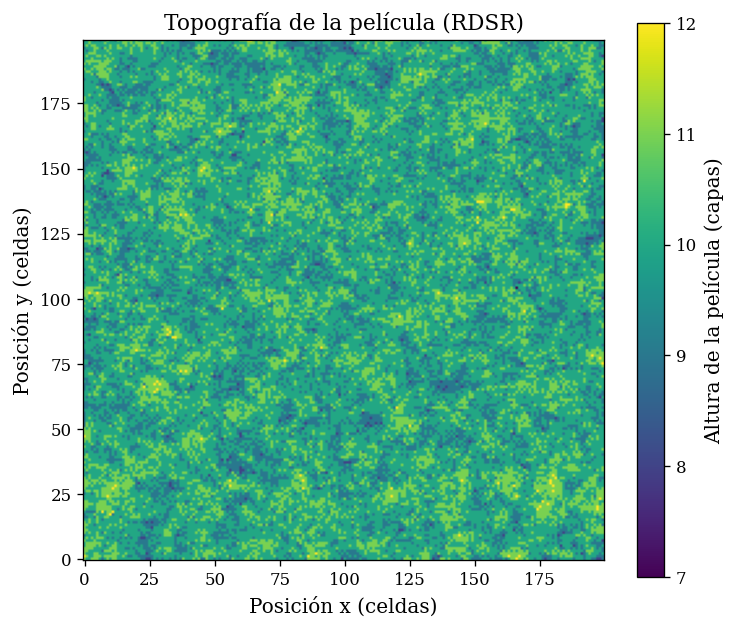

In [8]:
# Topografía bidimensional de la película (mapa de alturas)
fig, ax = plt.subplots(figsize=(7, 6))
# Se transpone la matriz para que el eje horizontal sea x (primer índice de la
# malla) y el vertical sea y (segundo índice); imshow dibuja el primer índice en vertical.
imagen = ax.imshow(superficie_final.T, origin="lower", cmap="viridis")
fig.colorbar(imagen, ax=ax, label="Altura de la película (capas)")
ax.set_xlabel("Posición x (celdas)")
ax.set_ylabel("Posición y (celdas)")
ax.set_title("Topografía de la película (RDSR)")
fig.savefig("rdsr_topografia_superficie.png", bbox_inches="tight")
plt.show()

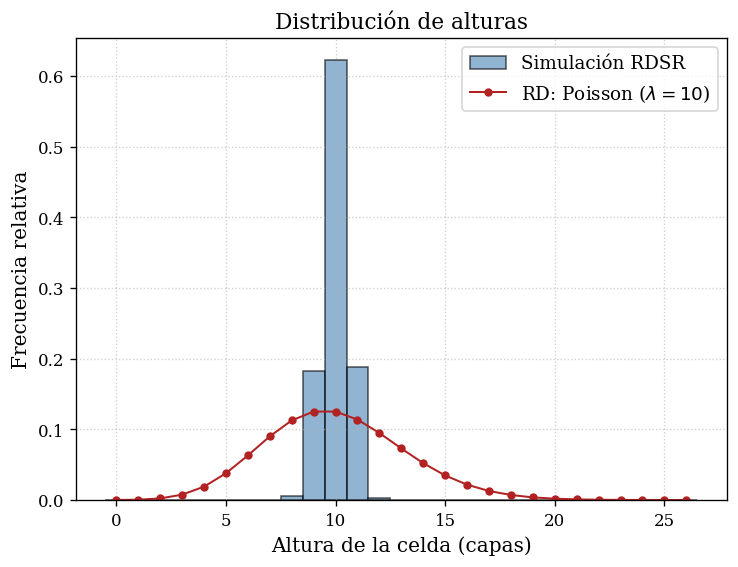

In [9]:
# Distribución de alturas frente a la estadística de Poisson del modelo RD
# El rango llega hasta donde la distribución de Poisson de referencia tiene peso
# apreciable, para que el contraste de anchuras sea visible.
altura_sup = max(int(alt_maxima), int(np.ceil(espesor_teo + 5 * rugosidad_rd)))
bordes = np.arange(0, altura_sup + 2) - 0.5          # un intervalo de anchura unidad por altura entera
alturas_enteras = np.arange(0, altura_sup + 1)

fig, ax = plt.subplots(figsize=(7, 5))
# Con density=True e intervalos de anchura unidad, la altura de cada barra es la
# frecuencia relativa de esa altura.
ax.hist(
    superficie_final.ravel(),
    bins=bordes,
    density=True,
    edgecolor="black",
    alpha=0.6,
    color="steelblue",
    label="Simulación RDSR",
)
ax.plot(
    alturas_enteras,
    poisson.pmf(alturas_enteras, espesor_teo),
    "o-",
    color="firebrick",
    markersize=4,
    linewidth=1.2,
    label=rf"RD: Poisson ($\lambda = {espesor_teo:g}$)",
)
ax.set_xlabel("Altura de la celda (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribución de alturas")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.savefig("rdsr_histograma_alturas.png", bbox_inches="tight")
plt.show()

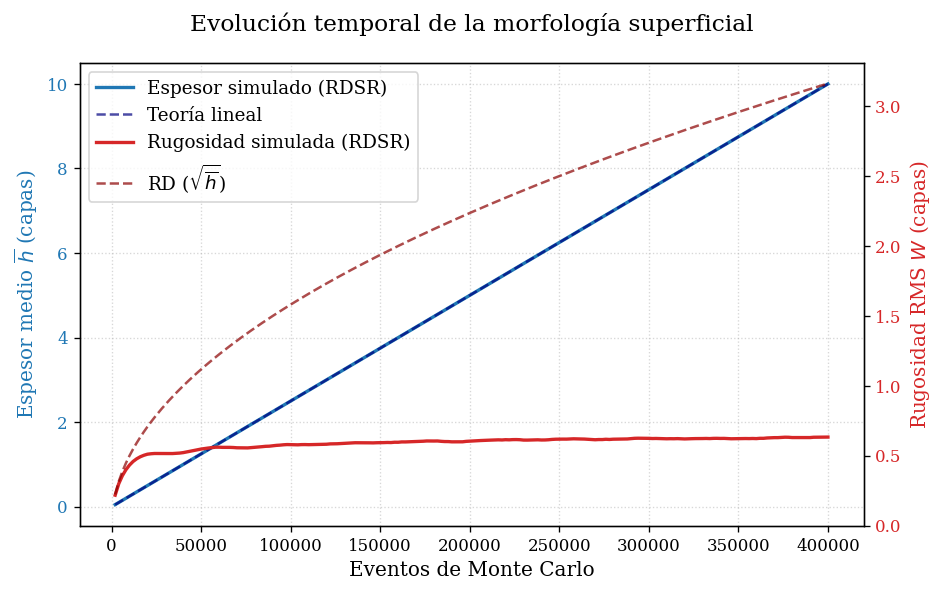

In [10]:
# Evolución temporal del espesor medio y de la rugosidad
fig, ax1 = plt.subplots(figsize=(8, 5))

color_esp = "tab:blue"
ax1.set_xlabel("Eventos de Monte Carlo")
ax1.set_ylabel(r"Espesor medio $\overline{h}$ (capas)", color=color_esp)
ax1.plot(eventos, hist_espesor, label="Espesor simulado (RDSR)", color=color_esp, linewidth=2)
ax1.plot(eventos, eventos / n_celdas, "--", label="Teoría lineal", color="navy", alpha=0.7)
ax1.tick_params(axis="y", labelcolor=color_esp)
ax1.grid(True, linestyle=":", alpha=0.5)

# Segundo eje vertical para la rugosidad, cuya escala numérica es distinta.
ax2 = ax1.twinx()
color_rug = "tab:red"
ax2.set_ylabel(r"Rugosidad RMS $W$ (capas)", color=color_rug)
ax2.plot(eventos, hist_rugosidad, label="Rugosidad simulada (RDSR)", color=color_rug, linewidth=2)
ax2.plot(
    eventos,
    np.sqrt(eventos / n_celdas),
    "--",
    label=r"RD ($\sqrt{\overline{h}}$)",
    color="darkred",
    alpha=0.7,
)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=color_rug)

fig.suptitle("Evolución temporal de la morfología superficial")
fig.tight_layout()

# Una sola leyenda con las curvas de ambos ejes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left")
fig.savefig("rdsr_evolucion_temporal.png", bbox_inches="tight")
plt.show()

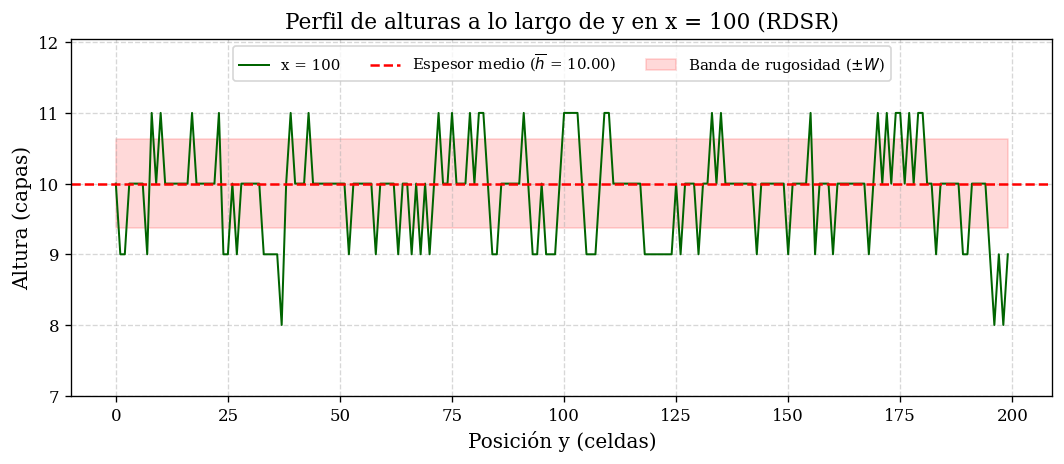

In [11]:
# Perfil unidimensional: alturas a lo largo de y en la coordenada x central
x_central = NX // 2
perfil = superficie_final[x_central, :]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(perfil, color="darkgreen", linewidth=1.2, label=f"x = {x_central}")
ax.axhline(
    espesor_sim,
    color="red",
    linestyle="--",
    label=rf"Espesor medio ($\overline{{h}}$ = {espesor_sim:.2f})",
)
ax.fill_between(
    range(NY),
    espesor_sim - rugosidad_sim,
    espesor_sim + rugosidad_sim,
    color="red",
    alpha=0.15,
    label=r"Banda de rugosidad ($\pm W$)",
)
ax.set_title(f"Perfil de alturas a lo largo de y en x = {x_central} (RDSR)")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura (capas)")
ax.grid(True, linestyle="--", alpha=0.5)
# Margen superior para que la leyenda no tape el perfil.
ax.set_ylim(perfil.min() - 1, perfil.max() + 0.35 * (perfil.max() - perfil.min()))
ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("rdsr_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

## 8. Análisis de resultados

### 8.1 Conservación de partículas y espesor medio

El espesor medio simulado coincide con $N/(N_x N_y) = 10$ capas y su error relativo es nulo. Se trata de una identidad y no de una prueba estadística: la relajación cambia la celda que recibe la partícula, pero cada evento añade exactamente una capa al total, de modo que la suma de las alturas es $N$ por construcción. La comparación funciona como control de calidad del código, y la ejecución verifica además de forma explícita que $\sum h = N$.

### 8.2 Reducción de la rugosidad

Con el mismo espesor medio, la rugosidad del modelo RD es $W_{\mathrm{RD}} = \sqrt{10} \approx 3.16$ capas. La rugosidad simulada con relajación es del orden de $0.6$ capas, unas cinco veces menor; la salida de la sección 6 informa el cociente y la reducción de la realización ejecutada. La diferencia se debe a que, en RD, las alturas de celdas vecinas son independientes y la varianza de cada una crece con el número de partículas recibidas. En RDSR, una partícula que incide sobre una celda más alta que sus vecinos se desplaza a uno de ellos, y una celda más baja que su entorno recibe material tanto de los impactos sobre ella como de los impactos sobre sus vecinos. Así se generan correlaciones entre alturas vecinas y se frena el crecimiento de las fluctuaciones. En el límite continuo este efecto corresponde al término difusivo $\nu \nabla^2 h$ de la ecuación EW.

El histograma de alturas muestra el mismo contraste: la distribución simulada es mucho más estrecha que la distribución de Poisson del modelo RD, que se extiende hasta alturas de unas 25 capas.

### 8.3 Evolución temporal

Al comienzo, con el sustrato casi vacío, las diferencias de altura entre celdas vecinas son escasas y la rugosidad apenas se distingue de la del modelo RD. Cuando aumenta la cobertura, la relajación se activa y $W$ deja de seguir la curva $\sqrt{\overline{h}}$. A partir de ahí crece de forma lenta, con un exponente efectivo (sección 6) muy inferior al valor $1/2$ de RD. Este comportamiento es compatible con el crecimiento logarítmico que la ecuación EW predice en dos dimensiones. La rugosidad no satura en el tiempo simulado, como se espera para 10 capas depositadas sobre una malla de lado $L = 200$.

### 8.4 Alturas extremas y cobertura del sustrato

Las alturas se confinan en un intervalo de pocas capas alrededor del espesor medio, con una altura mínima del orden de 7 capas. En el modelo RD se esperan $M e^{-\lambda} \approx 1.8$ celdas sin cubrir, y con relajación no aparecen celdas vacías, de modo que la película cubre todo el sustrato. Los picos y valles profundos de RD se evitan porque las partículas que caen sobre un pico se desplazan hacia un vecino más bajo.

### 8.5 Alcance del modelo

El modelo mantiene la aproximación SOS, sin huecos ni voladizos, y la relajación ocurre en un solo paso hacia los vecinos inmediatos con fronteras abiertas. La regla no depende de la temperatura: supone que la energía siempre basta para que la partícula alcance el sitio más bajo de su vecindad.

## 9. Conclusiones

* Se implementó una generalización bidimensional del modelo de deposición aleatoria con relajación superficial sobre una malla SOS, con un ciclo Monte Carlo que se compila con Numba cuando está disponible. La conservación del número de partículas se verifica de forma explícita en cada ejecución.

* Con el mismo espesor medio, la rugosidad RMS con relajación es unas cinco veces menor que la del modelo RD ($\sqrt{\overline{h}}$). El crecimiento de $W$ se desacelera respecto al exponente $1/2$ de RD, con un exponente efectivo muy inferior, y la película cubre todo el sustrato sin celdas vacías.

* La regla de relajación es instantánea, se limita a los vecinos inmediatos y no depende de la temperatura. El siguiente cuaderno de la serie reemplaza esta regla por una caminata aleatoria cuya probabilidad de salto depende de la temperatura del sustrato a través de una probabilidad efectiva.

## 10. Referencias

**Fuentes académicas primarias**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.

* Buceta, R. C., Hansmann, D., & von Haeften, B. (2014). *Revisiting random deposition with surface relaxation: Approaches from growth rules to Edwards-Wilkinson equation*. arXiv. https://arxiv.org/abs/1409.7463

* Edwards, S. F., & Wilkinson, D. R. (1982). The surface statistics of a granular aggregate. *Proceedings of the Royal Society of London A, 381*(1780), 17–31. https://doi.org/10.1098/rspa.1982.0056

* Family, F. (1986). Scaling of rough surfaces: Effects of surface diffusion. *Journal of Physics A: Mathematical and General, 19*(8), L441–L446. https://doi.org/10.1088/0305-4470/19/8/006

* Family, F., & Vicsek, T. (1985). Scaling of the active zone in the Eden process on percolation networks and the ballistic deposition model. *Journal of Physics A: Mathematical and General, 18*(2), L75–L81. https://doi.org/10.1088/0305-4470/18/2/005

* Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

* Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15) (Artículo 7, pp. 1–6). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

* Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

**Recursos complementarios**

* Numba. (s. f.). *Supported NumPy features*. Numba documentation. https://numba.pydata.org/numba-doc/latest/reference/numpysupported.html